# Feature Engineering
### Tolong baca perintah dan tagar komen dengan saksama!!

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [5]:
# untuk plot Q-Q
import scipy.stats as stats

In [6]:
df_california = pd.read_csv('california_dataset.csv')

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
train_clfr, test_clfr = train_test_split(df_california, test_size = 0.2, random_state=42)

#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

## **Practice 1. Outlier Handling**

### Practice 1.a :
1. Pilihlah salah satu kolom ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] pada dataset california_dataset.csv untuk melihat plot distribusi/plot visualisasi data dan outliernya

In [8]:
df_california = pd.read_csv('california_dataset.csv')
df_california.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,house_price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Practice 1.b
1. setelah mengecek distribusinya/visualisasiny, lakukan handling outlier dari kolom yang kamu pilih dengan metode IQR
2. Dan cek visualisasinya kembali

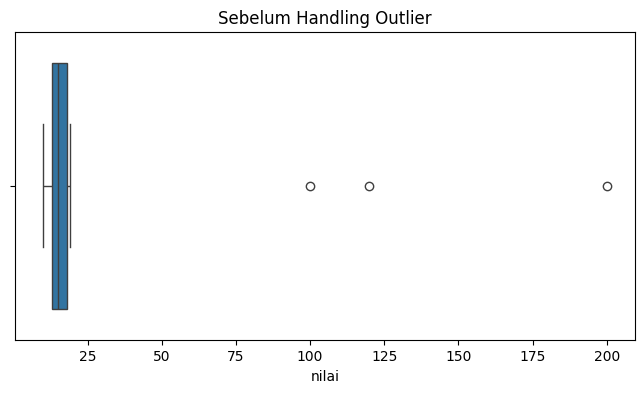

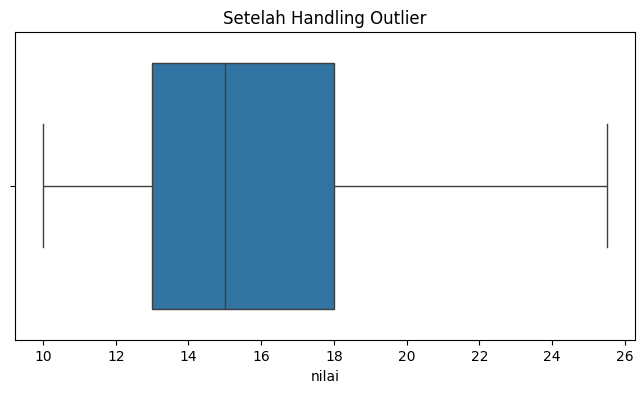

In [9]:
# Sekarang mari kita ganti outlier dengan batas maksimum dan minimum
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Contoh dataset
data = {'nilai': [10, 12, 15, 14, 100, 200, 13, 17, 11, 120, 14, 16, 15, 18, 19, 14, 13]}
df = pd.DataFrame(data)

# Visualisasi awal
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['nilai'])
plt.title("Sebelum Handling Outlier")
plt.show()

# Hitung Q1, Q3, dan IQR
Q1 = df['nilai'].quantile(0.25)
Q3 = df['nilai'].quantile(0.75)
IQR = Q3 - Q1

# Hitung batas bawah dan batas atas
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Ganti outlier dengan batas bawah/atas
df['nilai'] = np.where(df['nilai'] < batas_bawah, batas_bawah, df['nilai'])
df['nilai'] = np.where(df['nilai'] > batas_atas, batas_atas, df['nilai'])

# Visualisasi setelah handling outlier
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['nilai'])
plt.title("Setelah Handling Outlier")
plt.show()


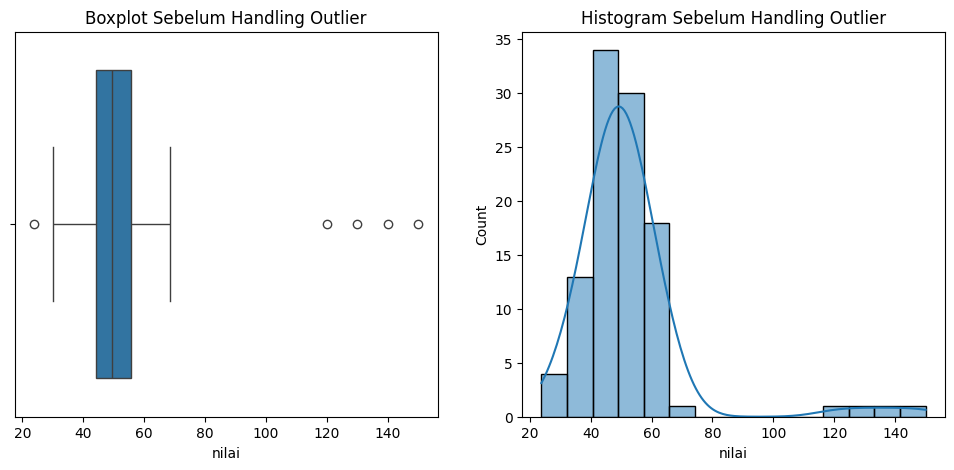

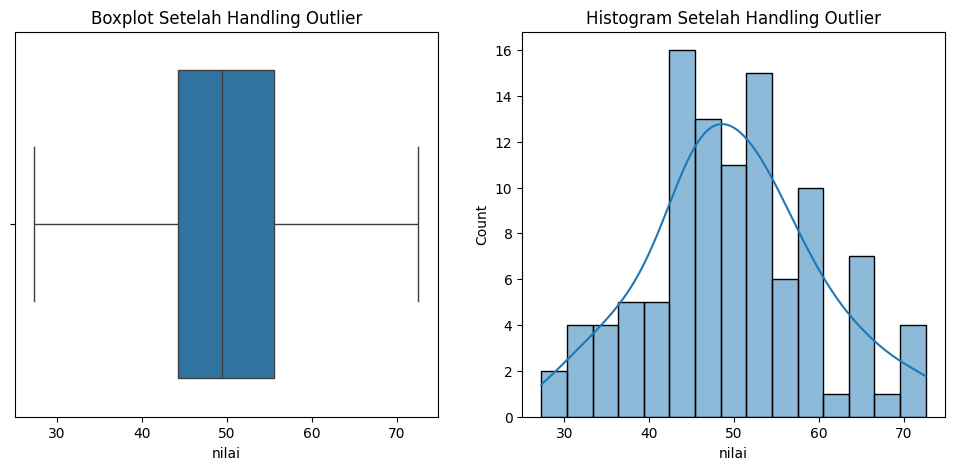

In [10]:
### Practice 1.b Setelah mengecek distribusinya, lakukan handling outlier dari kolom yang kamu pilih dengan metode IQR
### Dan cek distribusinya/visualisasinya kembali
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Contoh dataset
np.random.seed(42)
data = {'nilai': np.append(np.random.normal(50, 10, 100), [120, 130, 140, 150])}  # Tambah outlier
df = pd.DataFrame(data)

# Visualisasi distribusi awal
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['nilai'])
plt.title("Boxplot Sebelum Handling Outlier")

plt.subplot(1, 2, 2)
sns.histplot(df['nilai'], bins=15, kde=True)
plt.title("Histogram Sebelum Handling Outlier")

plt.show()

# Hitung Q1, Q3, dan IQR
Q1 = df['nilai'].quantile(0.25)
Q3 = df['nilai'].quantile(0.75)
IQR = Q3 - Q1

# Hitung batas bawah dan batas atas
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Ganti outlier dengan batas bawah/atas
df['nilai'] = np.where(df['nilai'] < batas_bawah, batas_bawah, df['nilai'])
df['nilai'] = np.where(df['nilai'] > batas_atas, batas_atas, df['nilai'])

# Visualisasi distribusi setelah handling outlier
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['nilai'])
plt.title("Boxplot Setelah Handling Outlier")

plt.subplot(1, 2, 2)
sns.histplot(df['nilai'], bins=15, kde=True)
plt.title("Histogram Setelah Handling Outlier")

plt.show()


# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [11]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [12]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Contoh dataset dengan missing values
data = {
    'age': [25, 30, np.nan, 35, 40, 29, np.nan, 50, 45, np.nan],  # Numerik
    'salary': [5000, 6000, 7000, 8000, np.nan, 10000, 11000, np.nan, 13000, 14000],  # Numerik
    'job_role': ['Engineer', 'Manager', 'Analyst', np.nan, 'Director', 'Engineer', 'Manager', 'Analyst', np.nan, 'CEO']  # Kategorik
}

df = pd.DataFrame(data)

# Cek missing values awal
print("Missing Values Sebelum Handling:\n", df.isnull().sum())

# Handling Missing Values
df['age'].fillna(df['age'].median(), inplace=True)  # Median untuk numerik
df['salary'].fillna(df['salary'].median(), inplace=True)  # Median untuk numerik
df['job_role'].fillna(df['job_role'].mode()[0], inplace=True)  # Mode untuk kategorik

# Cek missing values setelah handling
print("\nMissing Values Setelah Handling:\n", df.isnull().sum())

# Splitting dataset (contoh: 80:20)
train, test = train_test_split(df, test_size=0.2, random_state=42)

# Menampilkan jumlah data pada train dan test
print(f"\nTrain set: {train.shape[0]} data")
print(f"Test set: {test.shape[0]} data")

# Menampilkan sample hasil setelah preprocessing
print("\nSample Data Setelah Preprocessing:\n", train.head())

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

Missing Values Sebelum Handling:
 age         3
salary      2
job_role    2
dtype: int64

Missing Values Setelah Handling:
 age         3
salary      2
job_role    2
dtype: int64

Train set: 8 data
Test set: 2 data

Sample Data Setelah Preprocessing:
     age   salary  job_role
5  29.0  10000.0  Engineer
0  25.0   5000.0  Engineer
7  50.0      NaN   Analyst
2   NaN   7000.0   Analyst
9   NaN  14000.0       CEO


C:\Users\MOH SYURIL ISWAN\AppData\Local\Temp\ipykernel_30704\2173271867.py:20: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['age'].fillna(df['age'].median(), inplace=True)  # Median untuk numerik
C:\Users\MOH SYURIL ISWAN\AppData\Local\Temp\ipykernel_30704\2173271867.py:21: ChainedAssignmentError: A value is being set on a copy o

## **Practice 2. Missing Value Handling** :
1. Cek persentase missing value pada kolom Rating dan Revenue di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [17]:
#Tulis jawaban missing value handling kolom Rating dan Revenue disini
import pandas as pd

# Load dataset
df = pd.read_csv("company.csv")

# Cek jumlah dan persentase missing values
missing_values = df[['Rating', 'Revenue']].isnull().sum()
total_data = len(df)

missing_percentage = (missing_values / total_data) * 100
print("Persentase Missing Value:\n", missing_percentage)

# Keputusan Drop atau Handling
for col in ['Rating', 'Revenue']:
    if missing_percentage[col] > 20:
        print(f"⚠️ Kolom {col} memiliki lebih dari 20% missing values dan akan di-drop.")
        df.drop(columns=[col], inplace=True)
    else:
        # Handling Missing Value
        if df[col].dtype == 'object':  # Kategorik
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f"✅ Kolom {col} diisi dengan modus (mode).")
        else:  # Numerik
            df[col].fillna(df[col].median(), inplace=True)
            print(f"✅ Kolom {col} diisi dengan median.")

# Cek hasil setelah handling
print("\nMissing Values Setelah Handling:\n", df[['Rating', 'Revenue']].isnull().sum())


Persentase Missing Value:
 Rating     0.0
Revenue    0.0
dtype: float64
✅ Kolom Rating diisi dengan median.


C:\Users\MOH SYURIL ISWAN\AppData\Local\Temp\ipykernel_30704\765464913.py:25: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)


TypeError: Cannot perform reduction 'median' with string dtype

In [ ]:
df_company = pd.read_csv('company.csv')

In [ ]:
df_company.isna().sum()

,0
Revenue,0
Size,0
Rating,0
Headquarters,0


In [ ]:
for column in df_company.columns:
    print(f"============= {column} =================")
    display(df_company[column].value_counts())
    print()

============= Revenue =================


,count
Revenue,
Unknown / Non-Applicable,213
$100 to $500 million (USD),94
$10+ billion (USD),63
$2 to $5 billion (USD),45
$10 to $25 million (USD),41
$1 to $2 billion (USD),36
$25 to $50 million (USD),36
$50 to $100 million (USD),31
$1 to $5 million (USD),31



============= Size =================


,count
Size,
51 to 200 employees,135
1001 to 5000 employees,104
1 to 50 employees,86
201 to 500 employees,85
10000+ employees,80
501 to 1000 employees,77
5001 to 10000 employees,61
-1,27
Unknown,17



============= Rating =================


,count
Rating,
3.5,58
-1.0,50
4.0,41
3.3,41
3.9,40
3.8,39
3.7,38
5.0,36
4.5,32



============= Headquarters =================


,count
Headquarters,
"New York, NY",33
-1,31
"San Francisco, CA",31
"Chicago, IL",23
"Boston, MA",19
"Reston, VA",14
"Mc Lean, VA",13
"Westminster, CO",12
"Cambridge, United Kingdom",10


In [ ]:
100 * len(df_company[df_company['Rating']==-1]) / len(df_company)

7.440476190476191

In [ ]:
100 * len(df_company[df_company['Size'].isin(['-1','Unknown'])]) / len(df_company)

6.5476190476190474

In [ ]:
100 * len(df_company[df_company['Revenue'].isin(['-1','Unknown / Non-Applicable'])]) / len(df_company)

35.714285714285715

In [ ]:
df_company = df_company.drop(columns=['Revenue'])
df_company.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Size          672 non-null    object 
 1   Rating        672 non-null    float64
 2   Headquarters  672 non-null    object 
dtypes: float64(1), object(2)
memory usage: 15.9+ KB


In [ ]:
from sklearn.model_selection import train_test_split
train_company, test_company = train_test_split(df_company, test_size = 0.2, random_state=42)

In [ ]:
# Imputasi median pada kolom Rating : train

median_rating_train = train_company[train_company['Rating']!=-1]['Rating'].median()

In [ ]:
median_rating_train

3.8

In [ ]:
#menerapkan imputasi nilai yang hilang untuk melatih dan menguji, dari pemeringkatan nilai median dalam data train
train_company['Rating'] = train_company['Rating'].apply(lambda x: median_rating_train if x==-1 else x) #train
test_company['Rating'] = test_company['Rating'].apply(lambda x: median_rating_train if x==-1 else x) #test

In [ ]:
train_company['Rating'].value_counts()

,count
Rating,
3.8,72
3.5,47
3.3,35
4.0,34
3.9,33
5.0,31
3.7,28
4.5,25
3.6,25


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

## **Practice 3 Label Encoder :**
1. buatlah kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [ ]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')
# Mengganti "Yes" menjadi 1 dan "No" menjadi 0 dalam kolom "Churn"
df_churn['Churn'] = df_churn['Churn'].replace({'Yes': 1, 'No': 0})
df_churn.head()

FileNotFoundError: [Errno 2] No such file or directory: 'TelcoCustomerChurn.csv'

In [ ]:
#Splitting terlebih dahulu



In [ ]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder

# Kolom-kolom yang ingin di-label encode
columns_to_encode = ['StreamingMovies','StreamingTV', 'TechSupport', 'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'MultipleLines']

# Inisialisasi LabelEncoder
label_encoder = LabelEncoder()

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load dataset
df_churn = pd.read_csv("TelcoCustomerChurn.csv")

# Pilih kolom yang akan diencode
columns_to_encode = ['StreamingMovies', 'StreamingTV', 'TechSupport',
                     'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'MultipleLines']

# Ganti nilai "No internet service" menjadi "No"
df_churn[columns_to_encode] = df_churn[columns_to_encode].replace("No internet service", "No")

# Inisialisasi Label Encoder
le = LabelEncoder()

# Lakukan Label Encoding pada kolom yang dipilih
for col in columns_to_encode:
    df_churn[col] = le.fit_transform(df_churn[col])

# Ubah kolom "Churn" menjadi binary (Yes → 1, No → 0)
df_churn['Churn'] = df_churn['Churn'].replace({'Yes': 1, 'No': 0})

# Cek hasil perubahan
print(df_churn[columns_to_encode].head())
print("\nCek nilai unik setelah encoding:\n", df_churn[columns_to_encode].nunique())

# Menampilkan beberapa baris pertama setelah preprocessing
df_churn.head()


   StreamingMovies  StreamingTV  TechSupport  DeviceProtection  OnlineBackup  \
0                0            0            0                 0             1   
1                0            0            0                 1             0   
2                0            0            0                 0             1   
3                0            0            1                 1             0   
4                0            0            0                 0             0   

   OnlineSecurity  MultipleLines  
0               0              1  
1               1              0  
2               1              0  
3               1              1  
4               0              0  

Cek nilai unik setelah encoding:
 StreamingMovies     2
StreamingTV         2
TechSupport         2
DeviceProtection    2
OnlineBackup        2
OnlineSecurity      2
MultipleLines       3
dtype: int64


<ipython-input-29-0fa035d03a76>:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_churn['Churn'] = df_churn['Churn'].replace({'Yes': 1, 'No': 0})


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,1,DSL,0,1,0,0,0,0,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,0,DSL,1,0,1,0,0,0,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,2,Yes,0,DSL,1,1,0,0,0,0,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,1,DSL,1,0,1,1,0,0,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,0,Fiber optic,0,0,0,0,0,0,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Thank you :)